# Proyecto: Amigrante


Mi objetivo con este proyecto, es crear una aplicacion en la que se pueda dar a entender de manera eficaz y mas simplificada las leyes de extranjeria, para poder asesorar u orientar a una persona en situacion de ilegalidad migratoria en territorio Español. Mi idea nace, ya que como migrante se lo dificil que es entender las leyes y obtener la informacion necesaria para llevar un proceso migratorio exitoso, por eso quiero poder analizar el reglamento y poder hacer algo con mis conocimientos de migracion e informaticos para poder ayudar a quienes lo necesiten.

## Pasos a seguir:

- Paso 1: Obtener la informacion necesaria
- Paso 2: Analiazar el reglamento de migracion Ley Organica 4/2000
- Paso 3: Buscar patrones en los datos
- Paso 4: Ingenieria de caracteristicas
- Paso 5: Entrenamiento de un modelo que me ayude a predecir cuantoe exito podra tener una persona en X situacion migratoria
- Paso 6: Tests de los datos de entrenamiento y validacion de los resultados
- Paso 7: Hacer un despliegue de la aplicacion para que las personas puedan probar la aplicacion 

## Imports

In [2]:
import pandas as pd
import re
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber
import os
import spacy
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pyarrow

## Obtencion de datos

Obtendremos nuestros datos del Boletin Oficial del Estado BOE

In [3]:
ruta_pdf = r"/workspaces/Data-Science/data/raw/BOE-Ley-Organica-4-2000.pdf"

def pdf_a_dataframe(ruta_pdf):
    texto_completo = ""
    
    # 1. Extracción de texto
    with pdfplumber.open(ruta_pdf) as pdf:
        for pagina in pdf.pages:
            extraido = pagina.extract_text()
            if extraido:
                texto_completo += extraido + "\n"

    # 2. Limpieza básica (opcional: quitar encabezados comunes del BOE)
    texto_completo = re.sub(r'BOLETÍN OFICIAL DEL ESTADO.*?\n', '', texto_completo)

    # 3. Segmentación por Artículos
    # Buscamos el patrón "Artículo" seguido de un número y un punto
    patron_articulos = r'(Artículo\s+\d+\.?\s+)'
    partes = re.split(patron_articulos, texto_completo)
    
    datos = []
    # El split nos devuelve [texto_previo, "Artículo 1.", "contenido...", "Artículo 2.", ...]
    for i in range(1, len(partes), 2):
        num_articulo = partes[i].strip()
        contenido = partes[i+1].strip()
        
        datos.append({
            "Referencia": num_articulo,
            "Texto_Legal": contenido,
            "Longitud_Texto": len(contenido),
            "Palabras": len(contenido.split())
        })
    
    # 4. Creación del DataFrame
    return pd.DataFrame(datos)

In [4]:
df_ley = pdf_a_dataframe(ruta_pdf)
df_ley

,Referencia,Texto_Legal,Longitud_Texto,Palabras
0,Artículo 1.,Delimitación del ámbito.. . . . . . . . . . . ...,125,53
1,Artículo 2.,Exclusión del ámbito de la ley.. . . . . . . ....,124,52
2,Artículo 2,bis. La política inmigratoria.. . . . . . . . ...,127,52
3,Artículo 2,ter. Integración de los inmigrantes. . . . . ....,387,144
4,Artículo 3.,Derechos de los extranjeros e interpretación d...,110,34
...,...,...,...,...
179,Artículo 70.,El Foro para la Integración Social de los Inmi...,648,87
180,Artículo 71.,Observatorio Español del Racismo y la Xenofobi...,259,41
181,Artículo 72.,Comisión Laboral Tripartita de Inmigración.\n1...,24050,3637
182,Artículo 312.,1. Serán castigados con las penas de prisión d...,370,66


## Enrequeciremos nuestro dataset con NPL

In [5]:
categorias = {
    'Trabajo': ['contrato', 'empleador', 'cuenta ajena', 'cuenta propia', 'laboral'],
    'Residencia': ['permiso', 'estancia', 'renovación', 'larga duración', 'temporal'],
    'Familia': ['reagrupación', 'hijos', 'cónyuge', 'familiar', 'matrimonio'],
    'Sanciones': ['expulsión', 'multa', 'infracción', 'detención', 'salida obligatoria'],
    'Arraigo': ['arraigo social', 'arraigo laboral', 'arraigo familiar', 'formación']
}

In [6]:
def categorizar_articulo(texto):
    tags = []
    for categoria, palabras in categorias.items():
        if any(palabra in texto.lower() for palabra in palabras):
            tags.append(categoria)
    return ", ".join(tags) if tags else "General"

# Aplicamos la función al DataFrame
df_ley['Categorias'] = df_ley['Texto_Legal'].apply(categorizar_articulo)

In [7]:
# Añadimos métricas de densidad y complejidad
df_ley['Densidad_Legal'] = df_ley['Palabras'] / df_ley['Longitud_Texto']
df_ley['Es_Critico'] = df_ley['Categorias'].str.contains('Sanciones|Arraigo').astype(int)

# Visualizamos el DataFrame enriquecido
df_enriquecido_resumen = df_ley[['Referencia', 'Categorias', 'Palabras', 'Es_Critico']].head(10)
df_enriquecido_resumen

,Referencia,Categorias,Palabras,Es_Critico
0,Artículo 1.,General,53,0
1,Artículo 2.,General,52,0
2,Artículo 2,General,52,0
3,Artículo 2,General,144,0
4,Artículo 3.,General,34,0
5,Artículo 4.,General,49,0
6,Artículo 5.,General,47,0
7,Artículo 6.,General,52,0
8,Artículo 7.,General,44,0
9,Artículo 8.,General,52,0


In [8]:
# Cargamos el modelo de español
nlp = spacy.load("es_core_news_sm")

def limpiar_texto_legal(texto):
    # Procesamos el texto con el modelo de SpaCy
    doc = nlp(texto.lower())
    
    # Filtramos: 
    # - Solo palabras alfabéticas (quitamos números y signos de puntuación)
    # - Solo si NO son "stop words"
    # - Extraemos el "lema" (la raíz de la palabra)
    tokens_limpios = [token.lemma_ for token in doc 
                      if token.is_alpha and not token.is_stop]
    
    return " ".join(tokens_limpios)

# 1. Creamos la columna con el texto procesado para la "máquina"
df_ley['Texto_Limpio'] = df_ley['Texto_Legal'].apply(limpiar_texto_legal)

# 2. Generamos una métrica de "Riqueza Léxica" (Palabras únicas / Palabras totales)
def riqueza_lexica(texto):
    palabras = texto.split()
    if not palabras: return 0
    return len(set(palabras)) / len(palabras)

df_ley['Riqueza_Lexica'] = df_ley['Texto_Limpio'].apply(riqueza_lexica)

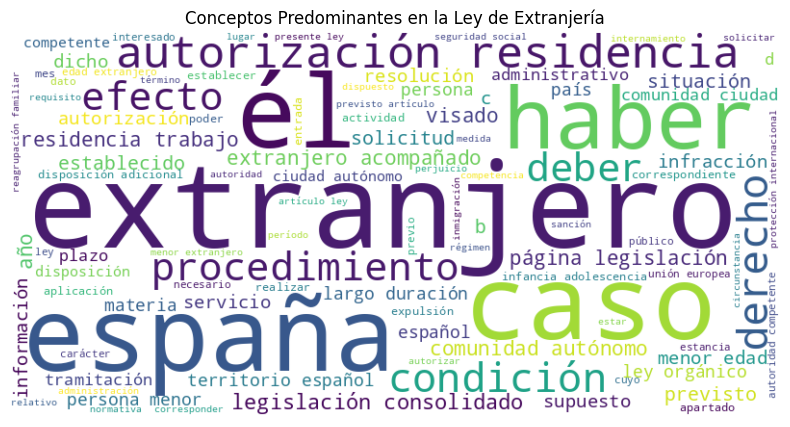

In [9]:
# Juntamos todo el texto limpio en un solo string
todo_el_texto = " ".join(df_ley['Texto_Limpio'])

# Configuramos la nube de palabras
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100).generate(todo_el_texto)

# Mostrar el gráfico
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Conceptos Predominantes en la Ley de Extranjería")
plt.show()

In [10]:
ranking_df = df_ley.nlargest(10, 'Palabras')[['Referencia', 'Categorias', 'Palabras', 'Riqueza_Lexica']]

# Añadimos una columna de "Prioridad de Asesoría"
# Si el artículo es largo y tiene categorías críticas, le asignamos prioridad Alta
def asignar_prioridad(row):
    if row['Palabras'] > 500 or "Sanciones" in row['Categorias']:
        return "Alta (Requiere Simplificación)"
    return "Media"

ranking_df['Prioridad_App'] = ranking_df.apply(asignar_prioridad, axis=1)

ranking_df

,Referencia,Categorias,Palabras,Riqueza_Lexica,Prioridad_App
181,Artículo 72.,"Trabajo, Residencia, Familia, Sanciones, Arraigo",3637,0.370650,Alta (Requiere Simplificación)
90,Artículo 72.,"Trabajo, Arraigo",1469,0.584541,Alta (Requiere Simplificación)
159,Artículo 57.,"Trabajo, Residencia, Familia, Sanciones, Arraigo",1243,0.473137,Alta (Requiere Simplificación)
131,Artículo 35.,"Trabajo, Familia, Arraigo",1003,0.539446,Alta (Requiere Simplificación)
134,Artículo 35,General,825,0.437500,Alta (Requiere Simplificación)
183,Artículo 318,"Residencia, Sanciones, Arraigo",806,0.609467,Alta (Requiere Simplificación)
175,Artículo 66.,"Residencia, Arraigo",727,0.530120,Alta (Requiere Simplificación)
109,Artículo 17.,"Residencia, Familia",722,0.526480,Alta (Requiere Simplificación)
157,Artículo 55.,Sanciones,710,0.594771,Alta (Requiere Simplificación)
162,Artículo 59,"Residencia, Familia, Sanciones",686,0.607717,Alta (Requiere Simplificación)


In [19]:
# 1. Cargamos un modelo potente en español
# 'paraphrase-multilingual-MiniLM-L12-v2' es ligero y excelente para español
# 

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 2. Convertimos todos los artículos en vectores (esto puede tardar unos segundos)
print("Generando vectores de la ley...")

def limpieza_profunda_pdf(texto):
    if not isinstance(texto, str):
        return ""
    
    # 1. Eliminar secuencias de puntos (comunes en índices: "Derecho a... 45")
    texto = re.sub(r'\.{2,}', ' ', texto)
    
    # 2. Eliminar números aislados al final o inicio de línea (paginación)
    texto = re.sub(r'^\s*\d+\s*|\s*\d+\s*$', ' ', texto)
    
    # 3. Eliminar caracteres especiales no deseados (manteniendo tildes y ñ)
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-4\s]', ' ', texto)
    
    # 4. Normalizar espacios en blanco (colapsar múltiples espacios en uno solo)
    texto = re.sub(r'\s+', ' ', texto)
    
    # 5. Convertir a minúsculas para uniformidad
    return texto.strip().lower()

df_ley['Texto_Limpio'] = df_ley['Texto_Legal'].apply(limpieza_profunda_pdf)

embeddings_ley = model.encode(df_ley['Texto_Limpio'].tolist(), show_progress_bar=True)


# 3. Guardamos los embeddings en el DataFrame (como una lista de vectores)
# Aseguramos que los vectores son listas estándar
# df_ley['Vector'] = df_ley['Vector'].apply(lambda x: x.tolist() if hasattr(x, 'tolist') else x)
df_ley['Vector'] = embeddings_ley.tolist()
# Guardamos en formato JSON
df_ley.to_json("ley_procesada.json", orient="records", force_ascii=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando vectores de la ley...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [15]:
# 1. Cargamos el nuevo modelo
# Es más pesado pero mucho más preciso para español legal
model = SentenceTransformer('intfloat/multilingual-e5-large')

# 2. IMPORTANTE: E5 requiere un prefijo para distinguir qué es una búsqueda
# Para los textos de la ley usamos: "passage: "
textos_con_prefijo = ["passage: " + str(t) for t in df_ley['Texto_Limpio'].tolist()]
embeddings_ley = model.encode(textos_con_prefijo, show_progress_bar=True, normalize_embeddings=True)

# Guardamos los nuevos vectores
df_ley['Vector'] = [v.tolist() for v in embeddings_ley]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [22]:
# 1. Definimos la función de limpieza (para evitar el NameError)
def limpieza_profunda_pdf(texto):
    if not isinstance(texto, str): return ""
    texto = re.sub(r'\.{2,}', ' ', texto) # Quita puntos suspensivos
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9\s]', ' ', texto) # Quita símbolos
    texto = re.sub(r'\s+', ' ', texto) # Normaliza espacios
    return texto.strip().lower()

# 2. Cargamos el modelo (Si ya lo cargaste antes, puedes saltar esta línea)
model = SentenceTransformer('intfloat/multilingual-e5-large')

df_ley['Texto_Enriquecido'] = df_ley['Categorias'] + ": " + df_ley['Texto_Limpio']
textos_contextuales = ["passage: " + t for t in df_ley['Texto_Enriquecido']]
# 3. Preparamos los vectores de la Ley con el prefijo "passage: "
# Asegúrate de que df_ley tenga la columna 'Texto_Legal'
df_ley['Texto_Limpio'] = df_ley['Texto_Legal'].apply(limpieza_profunda_pdf)
textos_con_prefijo = ["passage: " + t for t in df_ley['Texto_Limpio']]

print("Generando nuevos embeddings (E5)...")
embeddings_enriquecidos = model.encode(textos_contextuales, show_progress_bar=True, normalize_embeddings=True)
df_ley['Vector'] = [v.tolist() for v in embeddings_enriquecidos]

# 4. Definimos la función de búsqueda adaptada
def buscar_asesoria_pro(pregunta_usuario, df, top_n=3, umbral=0.65):
    # Limpieza y prefijo
    pregunta_limpia = limpieza_profunda_pdf(pregunta_usuario)
    query_formateada = f"query: {pregunta_limpia}"
    
    # Embedding de la pregunta
    vector_pregunta = model.encode([query_formateada], normalize_embeddings=True)
    matriz_vectores = np.vstack(df['Vector'].values)
    
    # Similitud
    similitudes = cosine_similarity(vector_pregunta, matriz_vectores)
    df['Similitud'] = similitudes[0]
    
    # Filtramos por el umbral de confianza (0.65 es un buen estándar)
    resultados = df[df['Similitud'] >= umbral].nlargest(top_n, 'Similitud')
    
    if resultados.empty:
        # Si nada supera el 65%, devolvemos un aviso en lugar de datos erróneos
        print(f"⚠️ Aviso: No encontré una referencia legal clara para '{pregunta_usuario}' (Máx. similitud: {df['Similitud'].max():.2f})")
        return pd.DataFrame() 
    
    return resultados[['Referencia', 'Categorias', 'Texto_Legal', 'Similitud']]



Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando nuevos embeddings (E5)...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [25]:
# --- TEST FINAL ---
pregunta = "Como puedo hacer pan?"
df_resultados = buscar_asesoria_pro(pregunta, df_ley)
df_resultados

,Referencia,Categorias,Texto_Legal,Similitud
55,Artículo 44.,General,Hecho imponible. . . . . . . . . . . . . . . ....,0.787851
45,Artículo 36.,General,Autorización de residencia y trabajo. . . . . ...,0.786474
46,Artículo 37.,Trabajo,Autorización de residencia y trabajo por cuent...,0.783986


Prueba 1:

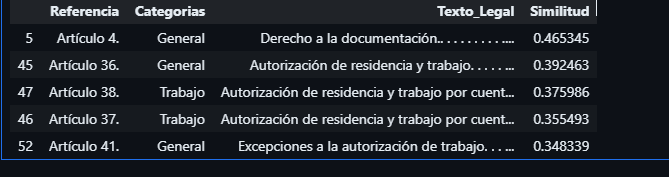

Prueba 2: 

![Captura de pantalla 2026-03-18 161347.png](<attachment:Captura de pantalla 2026-03-18 161347.png>)

Prueba 3:

![Captura de pantalla 2026-03-18 171137.png](<attachment:Captura de pantalla 2026-03-18 171137.png>)
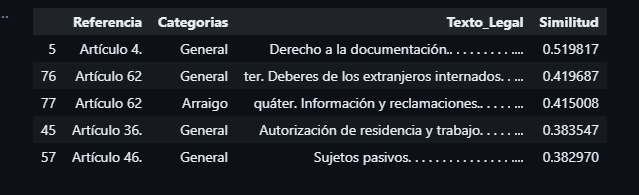
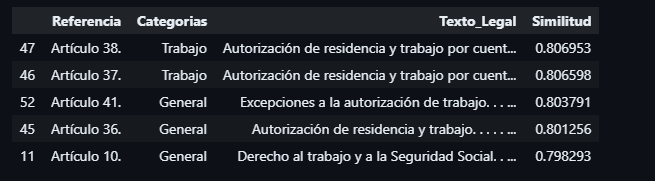